# Modeling U.S. Credit Response to Rising Interest Rates 

## Step 1: Imports & Environment Setup

### Imports

In [1]:
import pandas as pd
import sys
import os
from pathlib import Path
import yaml
import logging
from typing import Dict, Any, Optional, List
import matplotlib.pyplot as plt
from fredapi import Fred
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

### Verfiy Assets

In [2]:
logger = logging.getLogger("consumer-credit-analysis")

SECRETS_PATH = "../secrets.yaml"

if Path(SECRETS_PATH).exists():
        logger.info("secrets.yaml is properly configured.")
else:
    logger.info('secrets.yaml is not properly configured. Create a secrets.yaml file and add in your FRED API Key. i.e. `FRED_API_KEY:"XXXXXXXXXXXXXXXXXXXXXXX"`')


### Load Secrets File

In [3]:
def _load_yaml_file(path: str, name: str) -> Dict[str, Any]:
    """
    Helper to load any YAML file with a consistent error message.
    """
    abs_path = os.path.abspath(path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"{name} file not found at: {abs_path}")
    with open(abs_path, "r") as f:
        return yaml.safe_load(f) or {}

def load_secrets(secrets_path: str = "secrets.yaml") -> Dict[str, Any]:
    """
    Load application secrets from a YAML file.
    Args:
        secrets_path: Path to the secrets YAML file.

    Returns:
        Secrets dict.

    Raises:
        FileNotFoundError: If the secrets file is not found.
    """
    # If using an external secrets manager, you can create
    # an (empty) secrets.yaml stub in this path to satisfy the loader.
    return _load_yaml_file(secrets_path, "secrets.yaml")

secrets = load_secrets(SECRETS_PATH)
logger.info("Secrets Loaded")

### Setup FRED API Key

In [4]:
api_key = secrets.get("FRED_API_KEY")
fred = Fred(api_key=api_key)
logger.info("FRED API Key Successfully Setup.")

## Step 2: Data Download + Cleaning

In [5]:
# Download data
credit = fred.get_series('TOTALSL')
revolving = fred.get_series('REVOLSL')
nonrev = fred.get_series('NONREVSL')
fedfunds = fred.get_series('FEDFUNDS')

# Combine
df = pd.DataFrame({
    'credit_total': credit,
    'revolving': revolving,
    'nonrevolving': nonrev,
    'fedfunds': fedfunds
})

df = df.dropna()
logger.info("Datasets loaded and cleaned.")

## Step 3: Exploratory Data Analysis (EDA)

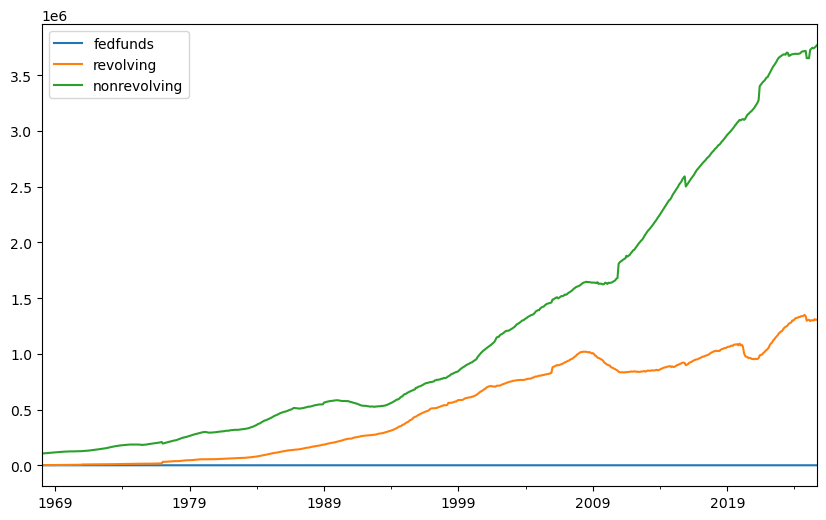

<Axes: xlabel='fedfunds', ylabel='revolving_growth'>

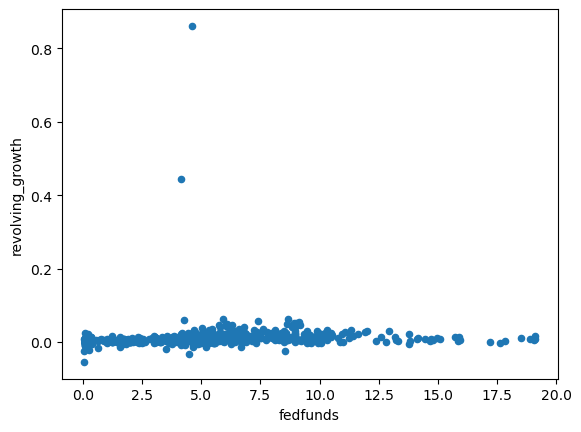

In [6]:
df['revolving_growth'] = df['revolving'].pct_change()
df['nonrev_growth'] = df['nonrevolving'].pct_change()

df[['fedfunds','revolving','nonrevolving']].plot(figsize=(10,6))
plt.show()

df.plot.scatter(x='fedfunds', y='revolving_growth')

## Step 4: Modeling

### Model 1: Linear Regression
Question: Do higher interest rates reduce revolving credit growth?

In [7]:
df_model = df[['fedfunds', 'revolving_growth']].dropna()

X = df_model[['fedfunds']]
y = df_model['revolving_growth']

print(X.shape, y.shape)  # sanity check: same number of rows

model1 = LinearRegression().fit(X, y)
print("coef:", model1.coef_, "intercept:", model1.intercept_)

(692, 1) (692,)
coef: [0.00117739] intercept: 0.004680503349725517


### Model 2: Random Forest Regression or ARIMAX
Simplest for slides: Random Forest

In [8]:
df_model2 = df[['fedfunds', 'nonrev_growth']].dropna()

X2 = df_model2[['fedfunds']]
y2 = df_model2['nonrev_growth']

print(X2.shape, y2.shape)  # sanity check: same length

model2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
).fit(X2, y2)

(692, 1) (692,)
